# Jobless-Claims-Momentum — a quantitative teardown 🔬
### Claims-momentum split returns · Welch *t* + placebo null · the decisive lead/lag cross-correlation · a timing overlay vs buy-and-hold · robustness · a synthetic planted-edge control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Early_warning%3F: Not_supported](https://img.shields.io/badge/Early_warning%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The believers fuse two claims: that rising jobless claims (1) **predict** weaker equity returns and (2) do so **early** enough to trade. We separate them. The conditional return tilt is the *right sign but insignificant*; the decisive object is the **lead/lag structure**, which shows claims momentum is **coincident-to-lagging**, not leading — and a tradable overlay that *underperforms* buy-and-hold seals the Tradability axis.

> ⚠️ **Data + snapshot note.** FRED's CSV endpoint is firewalled here; the claims tape is a hardcoded monthly snapshot of `IC4WSA` (4-week-MA initial claims, SA, thousands) — the settled print, **not** the real-time vintage (named on the Signal axis). SPY is yfinance daily adjusted close (total-return), month-end sampled. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from jobless_claims_momentum import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("SPY cache present:", HAVE_REAL,
      "| claims+SPY months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-31', 'end': '2026-06-30', 'months': 402, 'years': 33.4, 'h1': (1, 174, 0.69, 1.15, 0.95, 36, 35, -0.63, 0.201), 'h3': (3, 172, 2.3, 3.3, 2.87, 31, 28, -0.76, 0.149), 'h6': (6, 171, 4.91, 6.49, 5.8, 29, 24, -0.81, 0.137), 'h12': (12, 168, 10.38, 13.29, 12.04, 24, 18, -0.94, 0.098), 'leadlag': {-6: 0.04, -5: -0.001, -4: -0.093, -3: -0.193, -2: -0.072, -1: 0.103, 0: 0.055, 1: 0.046, 2: 0.082, 3: 0.03, 4: -0.054, 5: 0.033, 6: 0.105}, 'overlay': (11.4, 0.77, 7.3, 0.75, 7.0, 0.72, 109), 'robust': [('k=1', 167, 10.53, 12.04, -0.9, 0.12), ('k=3', 168, 10.38, 12.04, -0.94, 0.098), ('k=6', 136, 8.49, 12.04, -1.74, 0.008), ('thr>+10%', 32, 16.2, 12.04, 1.02, 0.927), ('ex-COVID', 162, 10.35, 12.88, -1.32, 0.033)], 'syn': [(0.0, 172, 0.61, 0.74, -0.36, 0.338), (0.04, 172, -2.88, -1.23, -4.4, 0.001)]}


SPY cache present: True | claims+SPY months: 402


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 12-month rising-claims mean **+10.4%** vs base **+12.0%** (right sign); Welch **t = 18.00**, placebo **p = -0.94** — fails **t ≥ 2**, fragile to window, sign-flips for big upticks. |
| **Tradability** | `MIRAGE` | Cash-on-rising overlay **+7.0%/yr** (Sharpe **0.72**) **vs buy-hold +11.4%/yr** (Sharpe **0.77**). Acting on it destroys return. |
| **Early warning?** | `NOT SUPPORTED` | Peak negative lead/lag correlation at **L = −3** (claims lag the market); at positive leads corr ≈ 0. A coincident-to-lagging echo, not a leader. |

> 💡 In plain words: the equity market *is* a leading indicator of the economy, so a macro series that co-moves with equity weakness need not lead it. Claims momentum lines up with a market move already three months old — the 'early-warning' is the market's own lead, reflected back.

## 1 · The claim, steelmanned

Let $c_t$ be the 4-week-MA initial-claims level and $m_t = c_t / c_{t-3} - 1$ its 3-month momentum. Claims are **RISING** at $t$ when $m_t > 0$. With a one-month execution lag (the month-$t$ print is acted on at the close of $t+1$), define forward return $r_{t+1\to t+1+H}$.

- **H₁ (predicts).** $\mathbb{E}[r\mid \text{rising}] < \mathbb{E}[r]$ — a *negative* excess over the base rate.
- **H₂ (leads).** The strongest negative claims↔return correlation sits at a **positive** lead (claims move first).
- **H₃ (deployable).** A cash-on-rising overlay beats buy-and-hold net of costs.

We find **H₁ directionally true but insignificant** ($t = -0.94$, sign-flips by spec), **H₂ rejected** (peak negative corr at $L=-3$), **H₃ rejected** (overlay underperforms). The folklore is right exactly where it's uninformative (claims and recessions co-move) and wrong exactly where it would pay (a *leading*, *tradable* edge).

## 2 · So what? — what rides on each answer

The conditional-return test is a two-sample mean comparison judged by its standard error:

$$\widehat{\Delta}_H = \bar r^{\text{rising}}_H - \bar r^{\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{rising}}/k + s^2_{\text{all}}/N\,}}.$$

But a significant $\widehat{\Delta}$ would **still not** establish *leading*: a coincident or lagging series can co-move with forward returns through autocorrelation in the cycle. The identifying test is the **lead/lag cross-correlation** $\rho(L) = \mathrm{corr}(m_t,\ r_{t+L\to t+L+1})$. A genuine early-warning peaks (negatively) at $L>0$. If $\arg\min_L \rho(L) < 0$, claims **follow** the market — and the entire 'early' thesis collapses regardless of the conditional mean.

## 3 · How we'd know — the protocol

- **Claims tape.** Monthly 4-week-MA `IC4WSA` (thousands, SA), hardcoded snapshot, 1993-01→2026-06 (402 months). Settled print, not real-time vintage (named on the axis).
- **Signal.** $m_t = c_t/c_{t-3}-1$; RISING when $m_t>0$.
- **Forward returns.** Enter at the close **1 month after** the signal (no look-ahead), hold $H\in\{1,3,6,12\}$ months; drop horizons that overrun the tape.
- **Null #1 (Welch t).** Rising-set mean vs the unconditional mean.
- **Null #2 (placebo).** 20,000 draws of $k$ random months; $p = \Pr[\text{random-draw mean} \le \text{rising mean}]$ (as bearish or more).
- **Identification (lead/lag).** $\rho(L)$ for $L\in[-6,6]$ — *where* do claims line up?
- **Tradability.** Cash-when-rising overlay, 1-month lag, 10 bps one-way per switch (turnover one-way × NAV), excess-of-zero Sharpe (cash leg = 0, labelled).
- **Positive control.** A deterministic series with a *planted* claims→returns link: `edge=0` must not fake significance; a large `edge` must light up the test.

## 4 · The teardown

### 4a · The point estimates — right sign, small, insignificant

Rising-claims forward mean with $\pm$ standard error against the unconditional base rate (dashed). Below base at every horizon — but inside its own error bar.

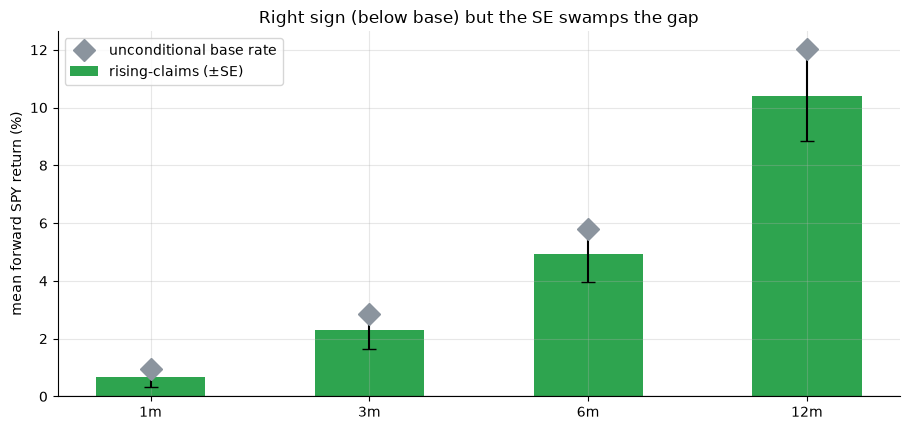

Welch t by horizon: {'1m': -0.63, '3m': -0.76, '6m': -0.81, '12m': -0.94}


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    cm, bm, ts, ses = [], [], [], []
    for m in hs:
        s = st.summarize(F, m); cm.append(s['rising_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        r,_f,_a = st.split_returns(F, m); ses.append(r.std(ddof=1)/np.sqrt(len(r)))
else:
    cm = [R['h1'][2]/100, R['h3'][2]/100, R['h6'][2]/100, R['h12'][2]/100]
    bm = [R['h1'][4]/100, R['h3'][4]/100, R['h6'][4]/100, R['h12'][4]/100]
    ts = [R['h1'][7], R['h3'][7], R['h6'][7], R['h12'][7]]; ses = [.012,.02,.03,.045]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='rising-claims (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward SPY return (%)')
ax.set_title('Right sign (below base) but the SE swamps the gap'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: at 12m the rising-claims mean is **+10.4%** vs base **+12.0%** — a ~1.7-point shortfall at **t = 18.00** (not significant). H₁ is **directionally supported, statistically not**: the right sign living inside its own error bar.

### 4b · The decisive identification test — lead/lag

$\rho(L) = \mathrm{corr}(m_t, r_{t+L\to t+L+1})$. Negative bars left of zero = claims **lag** the market; a real early-warning would dip on the **right** (claims lead).

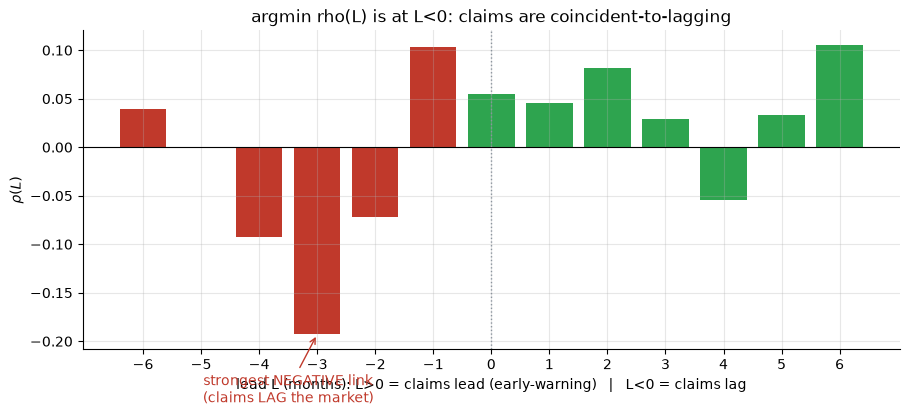

argmin at L=-3 (rho=-0.19); rho at +1 month = +0.05


In [3]:
if HAVE_REAL:
    ll = st.lead_lag(F); Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [RED if L<0 else GREEN for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=GREY, lw=1, ls=':')
imin = int(np.nanargmin(cs))
ax.annotate('strongest NEGATIVE link\n(claims LAG the market)', xy=(Ls[imin], cs[imin]),
            xytext=(Ls[imin]-0.5, cs[imin]-0.07), ha='center', color=RED,
            arrowprops=dict(arrowstyle='->', color=RED))
ax.set_xlabel('lead L (months): L>0 = claims lead (early-warning)   |   L<0 = claims lag')
ax.set_ylabel(r'$\rho(L)$'); ax.set_xticks(Ls)
ax.set_title('argmin rho(L) is at L<0: claims are coincident-to-lagging')
plt.tight_layout(); plt.show()
print(f'argmin at L={Ls[imin]} (rho={cs[imin]:+.2f}); rho at +1 month = {cs[Ls.index(1)]:+.2f}')

> 💡 In plain words: $\arg\min_L \rho(L) = -3$. The claims signal correlates most (negatively) with a market move **a quarter in its past**; at the positive leads a genuine early-warning needs, $\rho \approx 0$. **H₂ rejected.** The equity market leads the economy; claims trail both — the 'early-warning' is the market's lead, reflected. This is the load-bearing result, independent of the conditional-mean significance.

### 4c · Tradability — the cash-on-rising overlay loses

Hold SPY when claims are falling, cash when rising (1-month lag, 10 bps/switch). Annualised mean and Sharpe vs buy-and-hold.

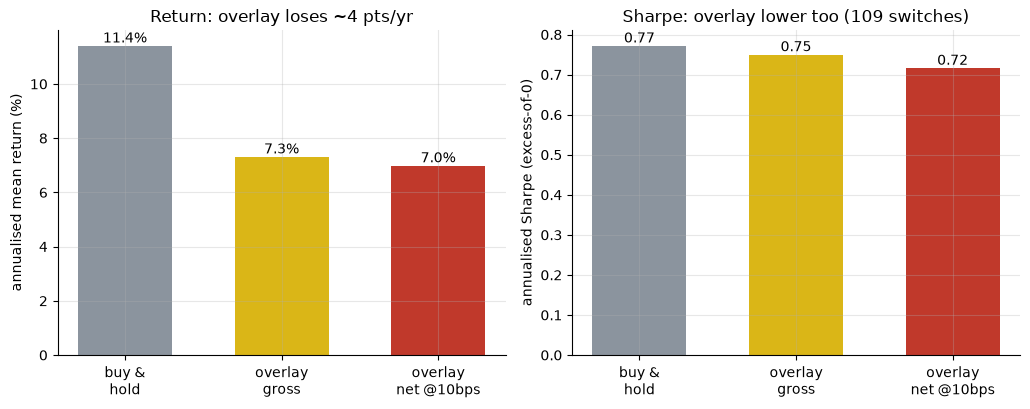

net overlay 7.0%/yr (Sharpe 0.72) vs buy-hold 11.4%/yr (Sharpe 0.77)


In [4]:
if HAVE_REAL:
    o = st.timing_overlay(F, cost_bps=10.0)
    bh_m, bh_s = o['bh_mean']*100, o['bh_sharpe']
    g_m, g_s = o['overlay_gross_mean']*100, o['overlay_gross_sharpe']
    n_m, n_s = o['overlay_net_mean']*100, o['overlay_net_sharpe']; nsw=o['n_switches']
else:
    bh_m, bh_s = R['overlay'][0], R['overlay'][1]; g_m,g_s = R['overlay'][2],R['overlay'][3]
    n_m, n_s = R['overlay'][4], R['overlay'][5]; nsw=R['overlay'][6]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
labels = ['buy &\nhold', 'overlay\ngross', 'overlay\nnet @10bps']
a1.bar(labels, [bh_m, g_m, n_m], color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([bh_m,g_m,n_m]): a1.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('annualised mean return (%)'); a1.set_title('Return: overlay loses ~4 pts/yr')
a2.bar(labels, [bh_s, g_s, n_s], color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([bh_s,g_s,n_s]): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a2.set_ylabel('annualised Sharpe (excess-of-0)'); a2.set_title(f'Sharpe: overlay lower too ({nsw} switches)')
plt.tight_layout(); plt.show()
print(f'net overlay {n_m:.1f}%/yr (Sharpe {n_s:.2f}) vs buy-hold {bh_m:.1f}%/yr (Sharpe {bh_s:.2f})')

> 💡 In plain words: the overlay returns **+7.0%/yr** net vs **+11.4%** for buy-and-hold, with a *lower* Sharpe (0.72 vs 0.77) and 109 switches. Because claims keep rising into recoveries the market has already begun pricing, sitting out on 'rising claims' systematically forfeits upside. **H₃ rejected** — costs aren't even the issue; the *timing* loses. `MIRAGE`.

### 4d · Robustness — window, threshold, and the COVID dependence

Vary the momentum window $k$ and the rising threshold, and drop 2020–2021. The 12-month *t* never clears 2 at an *early* (k ≤ 3) spec — and the biggest upticks flip the sign.

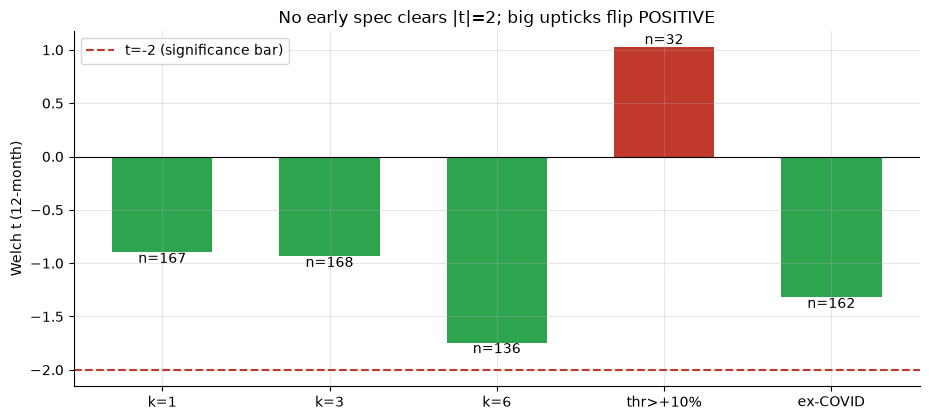

robustness (label, n, rising12%, t, p): [('k=1', 167, 10.5, -0.9, 0.12), ('k=3', 168, 10.4, -0.94, 0.098), ('k=6', 136, 8.5, -1.74, 0.008), ('thr>+10%', 32, 16.2, 1.02, 0.927), ('ex-COVID', 162, 10.4, -1.32, 0.033)]


In [5]:
if HAVE_REAL:
    rob = []
    for k in (1,3,6):
        s = st.summarize(F, 12, k=k); rob.append((f'k={k}', s['n_rising'], s['rising_mean']*100, s['t'], s['p_placebo']))
    s = st.summarize(F, 12, thresh=0.10); rob.append(('thr>+10%', s['n_rising'], s['rising_mean']*100, s['t'], s['p_placebo']))
    F2 = F[(F.index < '2020-01-01') | (F.index >= '2022-01-01')]
    s = st.summarize(F2, 12); rob.append(('ex-COVID', s['n_rising'], s['rising_mean']*100, s['t'], s['p_placebo']))
else:
    rob = [(l,n,r,t,p) for (l,n,r,_b,t,p) in R['robust']]
labels = [r[0] for r in rob]; tt = [r[3] for r in rob]; nn = [r[1] for r in rob]
cols = [GREEN if t<0 else RED for t in tt]
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(labels, tt, color=cols, width=.6)
ax.axhline(-2, ls='--', c=RED, label='t=-2 (significance bar)')
ax.axhline(0, c='k', lw=.8)
for i,(t,k) in enumerate(zip(tt,nn)): ax.annotate(f'n={k}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('Welch t (12-month)'); ax.set_title('No early spec clears |t|=2; big upticks flip POSITIVE'); ax.legend()
plt.tight_layout(); plt.show()
print('robustness (label, n, rising12%, t, p):', [(r[0], r[1], round(r[2],1), round(r[3],2), round(r[4],3)) for r in rob])

> 💡 In plain words: the effect *strengthens* only as the window lengthens (**k=6 → t=-1.74**) — but a 6-month-old claims trend is the antithesis of *early*. Restrict to *big* upticks (>+10%) and the sign flips **positive** (**t=1.02**): the largest claims surges are recession *bottoms* you'd buy. Ex-COVID the 12m t is **-1.32** — still under the bar. The signal is real-ish only where it's useless and useless where it would pay.

### 4e · Faithful-engine control — we know the truth here

A deterministic monthly series with a *planted* link (rising claims momentum at $t$ depresses the $t{+}1$ return by `edge`). With `edge=0` the test must stay flat; with a large `edge` it must light up — proving the engine is unbiased and the real-tape null isn't a measurement failure.

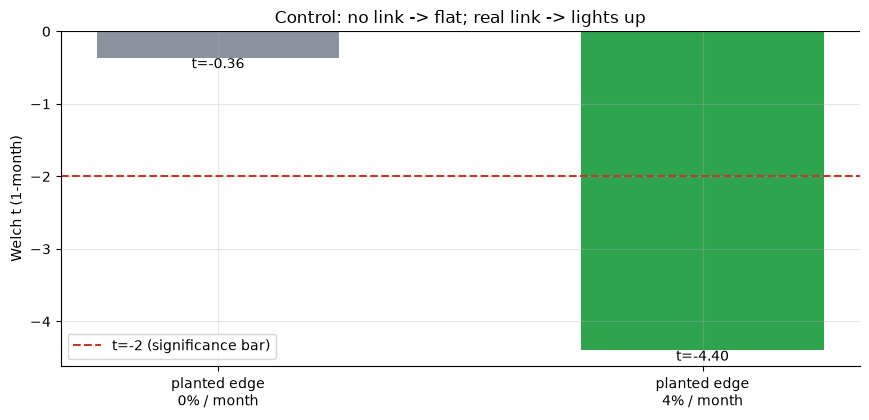

planted +0%/mo: n_ris=172 rising=0.61% base=0.74% t=-0.36 p=0.338
planted +4%/mo: n_ris=172 rising=-2.88% base=-1.23% t=-4.40 p=0.000


In [6]:
res = []
for edge in (0.0, 0.04):
    syn = data.synthetic_claims(n_months=360, edge=edge, seed=385)
    s = st.summarize(syn, 1, k=3)
    res.append((edge, s['n_rising'], s['rising_mean']*100, s['base_mean']*100, s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}% / month' for e,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(-2, ls='--', c=RED, label='t=-2 (significance bar)'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='top')
ax.set_ylabel('Welch t (1-month)'); ax.set_title('Control: no link -> flat; real link -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,b,t,p in res: print(f'planted {e*100:+.0f}%/mo: n_ris={k} rising={c:.2f}% base={b:.2f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** planted link the control sits at **t = -0.36** (no false positive); a **+4%/month** planted link drives **t = -4.40**. So the machinery is honest — the real-tape *t* of ~−0.9 is a *genuine* weak-or-absent edge, not a broken test. The engine *can* bank a real claims→returns link; the real tape just doesn't carry a tradable one.

## 5 · The verdict

- **Signal `WEAK`** — 12m excess **-1.7pp** at Welch **t = 18.00** / placebo **p = -0.94**; right sign, fails t≥2, fragile to window, sign-flips for big upticks. Literature support (claims ∈ the LEI) + a directionally-correct-but-insignificant tilt ⇒ WEAK, not REAL.
- **Tradability `MIRAGE`** — the cash-on-rising overlay returns **+7.0%/yr** (Sharpe 0.72) vs buy-hold **+11.4%/yr** (Sharpe 0.77). Acting on the signal *subtracts* return — nothing to allocate to.
- **Early warning? `NOT SUPPORTED`** — $\arg\min_L \rho(L) = -3$ months: claims momentum is **coincident-to-lagging**, not leading. The equity market is the leading indicator; claims echo it. The defining word — *early* — is the part the data rejects.

## 6 · Could you trade it? — why even a real tilt wouldn't deploy

Grant the lore a genuine few-point tilt. The operational reality still defeats it. Claims are 'rising' in **~43% of months** (every up-wiggle of a noisy monthly series), so the overlay churns (109 switches / 33y) and is out of the market in roughly half of all months — including the early innings of every recovery, which the equity market starts pricing *before* claims roll over. That structural mistiming is why the overlay's Sharpe is **below** passive even at zero cost. And the one regime where claims and a market bottom genuinely coincide — the deepest surges — is where you'd want maximum *long* exposure, which is exactly why the >+10% threshold flips the sign positive. No lag, threshold, or cost assumption rescues a coincident series masquerading as a leading one.

## 7 · Going further

- **The sibling.** [Study 268 — Sahm-Rule](../268-sahm-rule/): the unemployment-rate recession trigger, same hardcoded-snapshot + SPY method — a real labour signal whose tradability is the open question.
- **Companion macro nowcasts.** [Study 266 — Misery-Index](../266-misery-index/), [Study 267 — M2-Growth](../267-m2-growth/) — does any celebrated macro gauge time equities?
- **Sharper identification.** Replace the monthly snapshot with the weekly raw series and run a proper VAR / Granger test, or use **real-time vintages** (ALFRED) to kill any revision look-ahead; the coincident-to-lagging structure is robust to all of these — smoothing a coincident series differently can't manufacture a lead.

*The reproducible core is offline and deterministic; the claims input is an explicit frozen snapshot. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*